## **Preparando e Processando os Dados**

### **Importando os dados**

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/alura-cursos/data_science_projeto/main/Dados/bicicletas.csv')

In [4]:
df.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,NaN,NaN,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,NaN,NaN,93.0,6.5,Céu limpo,Não,Sim,Inverno


### **Tratando dados nulos**

In [5]:
df.shape

(17429, 10)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17429 entries, 0 to 17428
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_hora         17429 non-null  str    
 1   contagem          17429 non-null  int64  
 2   temperatura       17406 non-null  float64
 3   sensacao_termica  17406 non-null  float64
 4   umidade           17429 non-null  float64
 5   velocidade_vento  17429 non-null  float64
 6   clima             17429 non-null  str    
 7   feriado           17429 non-null  str    
 8   fim_de_semana     17429 non-null  str    
 9   estacao           17429 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 1.3 MB


In [7]:
df.isnull().sum()

data_hora            0
contagem             0
temperatura         23
sensacao_termica    23
umidade              0
velocidade_vento     0
clima                0
feriado              0
fim_de_semana        0
estacao              0
dtype: int64

In [8]:
# Utilizando método interpolate para preenchimento de dados nulos

df['temperatura'] = df['temperatura'].interpolate(method='linear')
df['sensacao_termica'] = df['sensacao_termica'].interpolate(method='linear')

In [9]:
df.head(10)

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno
5,2015-01-04 05:00:00,46,2.00,2.00,93.0,4.0,Céu limpo,Não,Sim,Inverno
6,2015-01-04 06:00:00,51,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
7,2015-01-04 07:00:00,75,1.00,-1.00,100.0,7.0,Parcialmente nublado,Não,Sim,Inverno
8,2015-01-04 08:00:00,131,1.50,-1.00,96.5,8.0,Parcialmente nublado,Não,Sim,Inverno
9,2015-01-04 09:00:00,301,2.00,-0.50,100.0,9.0,Nublado,Não,Sim,Inverno


### **Identificando e removendo dados duplicados**

In [10]:
df.duplicated().sum()

np.int64(15)

In [11]:
# Identificando as linhas duplicadas no DataFrame
duplicatas = df.duplicated(keep=False)

# Selecionando as linhas duplicadas com base no resultado anterior
linhas_duplicadas = df[duplicatas]

# Ordenando as linhas duplicadas pela coluna 'data_hora'
linhas_duplicadas.sort_values(by='data_hora')

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao
519,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
17422,2015-01-25 16:00:00,1238,8.0,5.0,71.0,18.0,Nublado,Não,Sim,Inverno
869,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
17417,2015-02-09 06:00:00,479,5.0,3.5,87.0,6.5,Parcialmente nublado,Não,Não,Inverno
3655,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
17425,2015-06-05 18:00:00,3411,23.0,23.0,50.0,26.0,Parcialmente nublado,Não,Não,Verão
4167,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
17421,2015-06-27 02:00:00,337,15.5,15.5,74.5,18.0,Parcialmente nublado,Não,Sim,Verão
4658,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão
17418,2015-07-17 14:00:00,1882,24.5,24.5,44.0,29.5,Parcialmente nublado,Não,Não,Verão


In [12]:
# Removendo dados duplicados

df_limpo = df.drop_duplicates()

In [13]:
df_limpo.shape

(17414, 10)

In [14]:
df_limpo.describe()

,contagem,temperatura,sensacao_termica,umidade,velocidade_vento
count,17414.000000,17414.000000,17414.000000,17414.000000,17414.000000
mean,1143.101642,12.468206,11.521080,72.324954,15.913063
std,1085.108068,5.571670,6.614799,14.313186,7.894570
min,0.000000,-1.500000,-6.000000,20.500000,0.000000
25%,257.000000,8.000000,6.000000,63.000000,10.000000
50%,844.000000,12.500000,12.500000,74.500000,15.000000
75%,1671.750000,16.000000,16.000000,83.000000,20.500000
max,7860.000000,34.000000,34.000000,100.000000,56.500000


## **Explorando Distribuições**

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

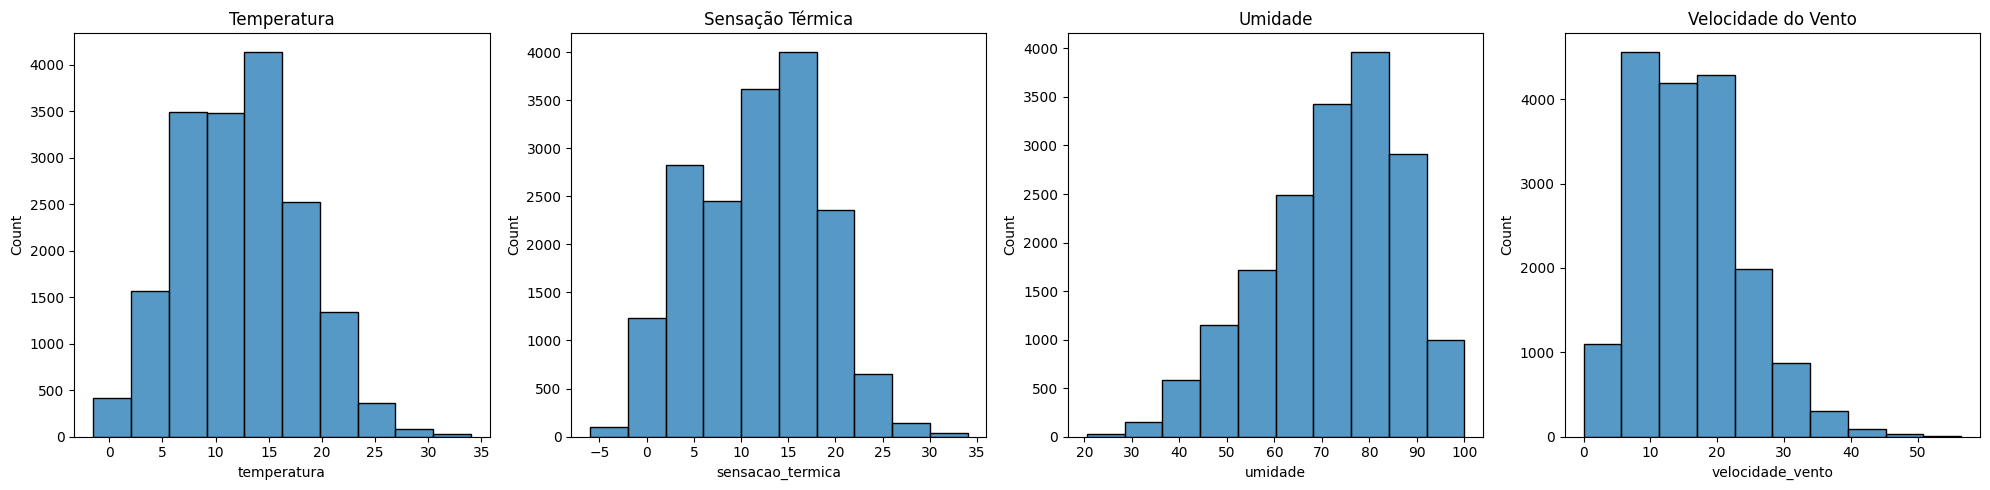

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.histplot(df_limpo['temperatura'], bins=10, ax=axes[0])
axes[0].set_title('Temperatura')

sns.histplot(df_limpo['sensacao_termica'], bins=10, ax=axes[1])
axes[1].set_title('Sensação Térmica')

sns.histplot(df_limpo['umidade'], bins=10, ax=axes[2])
axes[2].set_title('Umidade')

sns.histplot(df_limpo['velocidade_vento'], bins=10, ax=axes[3])
axes[3].set_title('Velocidade do Vento')

plt.tight_layout()
plt.show()

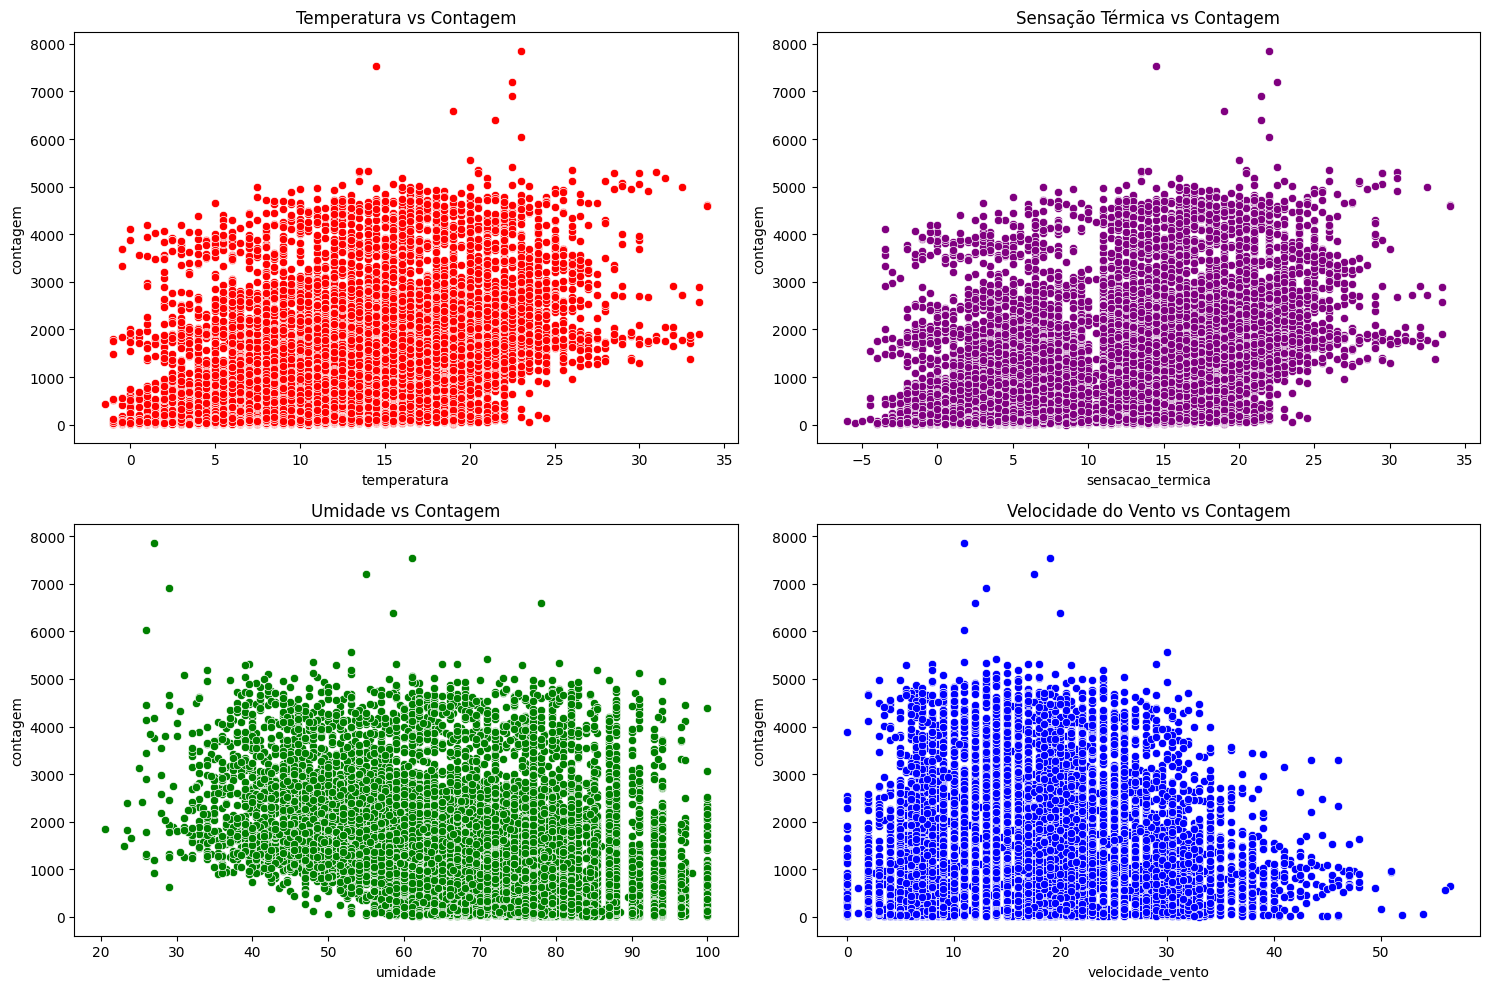

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.scatterplot(ax=axes[0, 0], data=df_limpo, x='temperatura', y='contagem', color='red')
axes[0, 0].set_title('Temperatura vs Contagem')
sns.scatterplot(ax=axes[0, 1], data=df_limpo, x='sensacao_termica', y='contagem', color='purple')
axes[0, 1].set_title('Sensação Térmica vs Contagem')
sns.scatterplot(ax=axes[1, 0], data=df_limpo, x='umidade', y='contagem', color='green')
axes[1, 0].set_title('Umidade vs Contagem')
sns.scatterplot(ax=axes[1, 1], data=df_limpo, x='velocidade_vento', y='contagem', color='blue')
axes[1, 1].set_title('Velocidade do Vento vs Contagem')

plt.tight_layout()
plt.show()

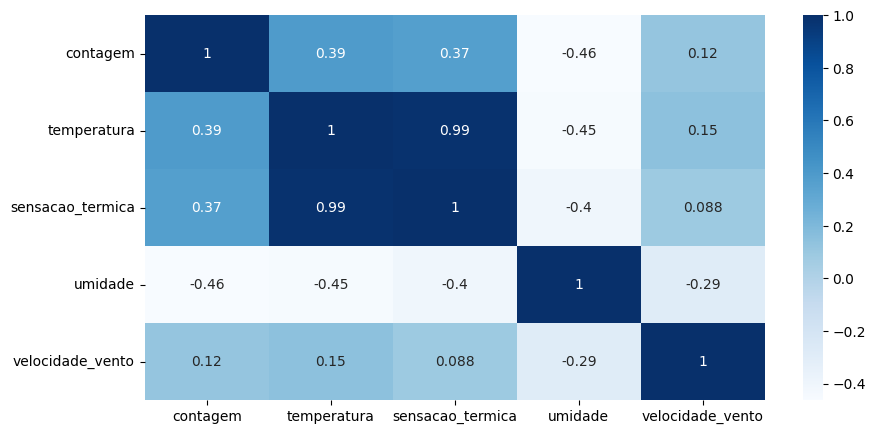

In [22]:
# Verificando correlações

plt.figure(figsize=(10,5))
sns.heatmap(df_limpo.corr(numeric_only=True), annot=True, cmap='Blues')
plt.show()

In [24]:
df_limpo.describe(include=['object', 'string'])

,data_hora,clima,feriado,fim_de_semana,estacao
count,17414,17414,17414,17414,17414
unique,17414,6,2,2,4
top,2015-01-04 00:00:00,Céu limpo,Não,Não,Primavera
freq,1,6150,17030,12444,4394


In [25]:
# Verificando categóricos unicos

for col in ['clima', 'feriado', 'fim_de_semana', 'estacao']:
    print(f'Coluna: {col}')
    print(df_limpo[col].unique())
    print('='*15,'\n')

Coluna: clima
<StringArray>
[             'Nublado',            'Céu limpo', 'Parcialmente nublado',
           'Chuva leve',                 'Neve',  'Chuva com trovoadas']
Length: 6, dtype: str

Coluna: feriado
<StringArray>
['Não', 'Sim']
Length: 2, dtype: str

Coluna: fim_de_semana
<StringArray>
['Sim', 'Não']
Length: 2, dtype: str

Coluna: estacao
<StringArray>
['Inverno', 'Primavera', 'Verão', 'Outono']
Length: 4, dtype: str



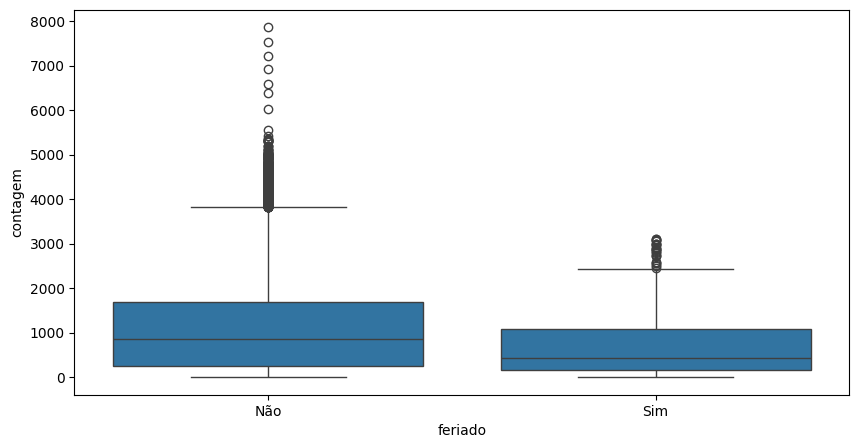

In [30]:
# Verificando outliers e distribuição com boxplot

plt.figure(figsize=(10,5))
sns.boxplot(data=df_limpo, x='feriado', y='contagem')
plt.show()

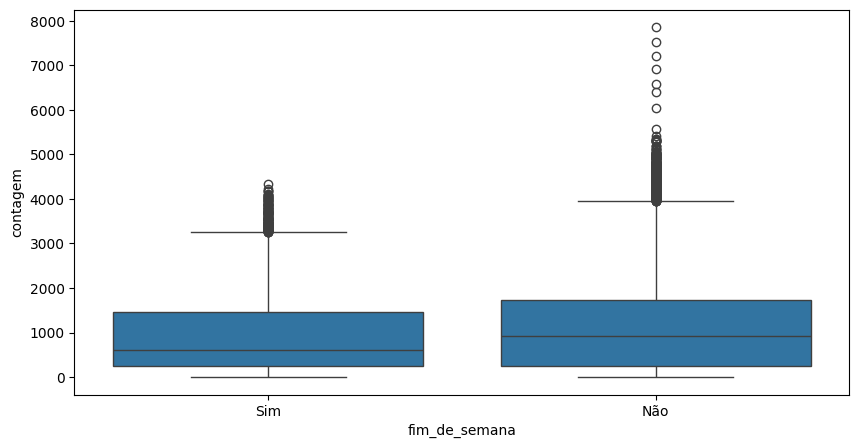

In [31]:
# Verificando outliers e distribuição com boxplot

plt.figure(figsize=(10,5))
sns.boxplot(data=df_limpo, x='fim_de_semana', y='contagem')
plt.show()

### Analisando de acordo com o tempo (data e hora)

In [32]:
df_limpo.info()

<class 'pandas.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_hora         17414 non-null  str    
 1   contagem          17414 non-null  int64  
 2   temperatura       17414 non-null  float64
 3   sensacao_termica  17414 non-null  float64
 4   umidade           17414 non-null  float64
 5   velocidade_vento  17414 non-null  float64
 6   clima             17414 non-null  str    
 7   feriado           17414 non-null  str    
 8   fim_de_semana     17414 non-null  str    
 9   estacao           17414 non-null  str    
dtypes: float64(4), int64(1), str(5)
memory usage: 1.3 MB


In [33]:
df_data = df_limpo.copy()

In [35]:
# Convertendo coluna para DateTime

df_data['data_hora'] = pd.to_datetime(df_data['data_hora'])

In [36]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   data_hora         17414 non-null  datetime64[us]
 1   contagem          17414 non-null  int64         
 2   temperatura       17414 non-null  float64       
 3   sensacao_termica  17414 non-null  float64       
 4   umidade           17414 non-null  float64       
 5   velocidade_vento  17414 non-null  float64       
 6   clima             17414 non-null  str           
 7   feriado           17414 non-null  str           
 8   fim_de_semana     17414 non-null  str           
 9   estacao           17414 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(4)
memory usage: 1.3 MB


In [37]:
# Criando novas colunas de mes e hora

df_data['mes'] = df_data['data_hora'].dt.month
df_data['hora'] = df_data['data_hora'].dt.hour


In [38]:
df_data.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,hora
0,2015-01-04 00:00:00,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04 01:00:00,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04 02:00:00,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04 03:00:00,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04 04:00:00,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [39]:
# Convertendo novamente para DateTime

df_data['data_hora'] = df_data['data_hora'].dt.date
df_data.head()

,data_hora,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,hora
0,2015-01-04,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [40]:
# Renomeando coluna de datas

df_data = df_data.rename(columns={'data_hora': 'data'})

In [42]:
df_data.head()

,data,contagem,temperatura,sensacao_termica,umidade,velocidade_vento,clima,feriado,fim_de_semana,estacao,mes,hora
0,2015-01-04,182,3.00,2.00,93.0,6.0,Nublado,Não,Sim,Inverno,1,0
1,2015-01-04,138,2.75,2.25,93.0,5.0,Céu limpo,Não,Sim,Inverno,1,1
2,2015-01-04,134,2.50,2.50,96.5,0.0,Céu limpo,Não,Sim,Inverno,1,2
3,2015-01-04,72,2.00,2.00,100.0,0.0,Céu limpo,Não,Sim,Inverno,1,3
4,2015-01-04,47,2.00,2.00,93.0,6.5,Céu limpo,Não,Sim,Inverno,1,4


In [43]:
# Convertendo para DateTime após Rename

df_data['data'] = pd.to_datetime(df_data['data'])

In [44]:
df_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   data              17414 non-null  datetime64[s]
 1   contagem          17414 non-null  int64        
 2   temperatura       17414 non-null  float64      
 3   sensacao_termica  17414 non-null  float64      
 4   umidade           17414 non-null  float64      
 5   velocidade_vento  17414 non-null  float64      
 6   clima             17414 non-null  str          
 7   feriado           17414 non-null  str          
 8   fim_de_semana     17414 non-null  str          
 9   estacao           17414 non-null  str          
 10  mes               17414 non-null  int32        
 11  hora              17414 non-null  int32        
dtypes: datetime64[s](1), float64(4), int32(2), int64(1), str(4)
memory usage: 1.5 MB


In [46]:
# Agrupando contagem por hora

df_por_hora = df_data.groupby('hora')['contagem'].sum().reset_index()

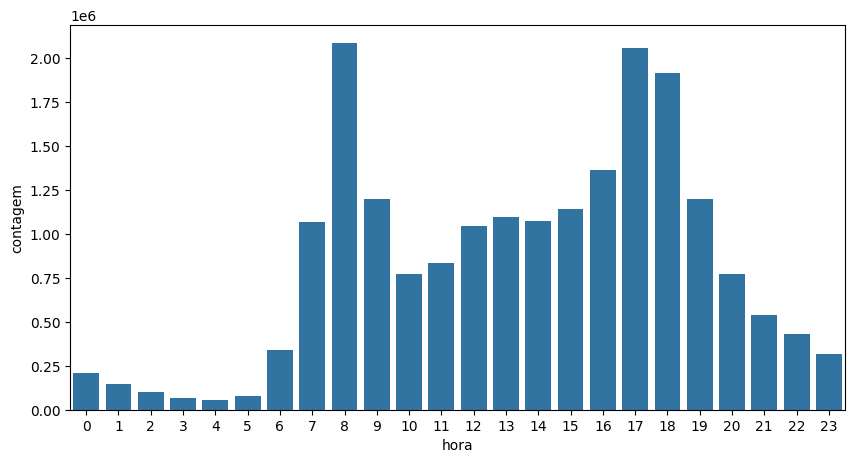

In [48]:
# Verificando distribuição por hora

plt.figure(figsize=(10,5))
sns.barplot(data=df_por_hora, x='hora', y='contagem')
plt.show()

In [49]:
# Verificando distribuição por hora no fim de semana

df_fim_de_semana = df_data[df_data['fim_de_semana'] == 'Sim']
alugueis_fim_semana = df_fim_de_semana.groupby('hora')['contagem'].sum().reset_index()

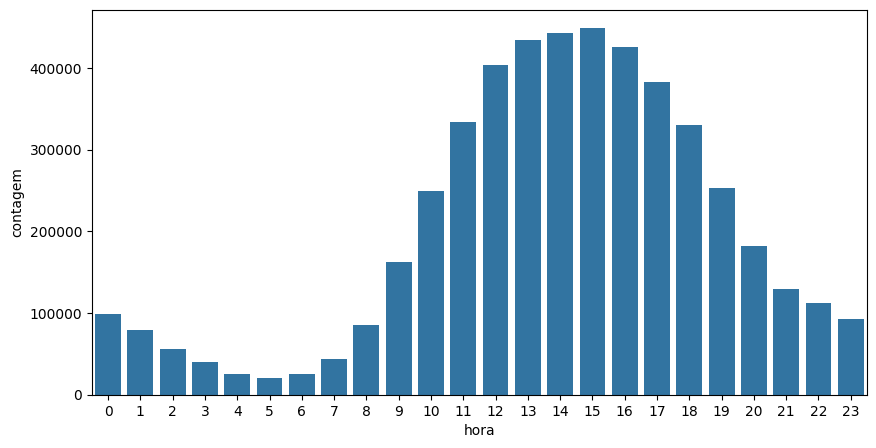

In [50]:
plt.figure(figsize=(10,5))
sns.barplot(alugueis_fim_semana, x='hora', y='contagem')
plt.show()

### Analisando por data

In [51]:
# Verificando distribuição ao longo do tempo

df_tempo = df_data.groupby('data')['contagem'].sum().reset_index()

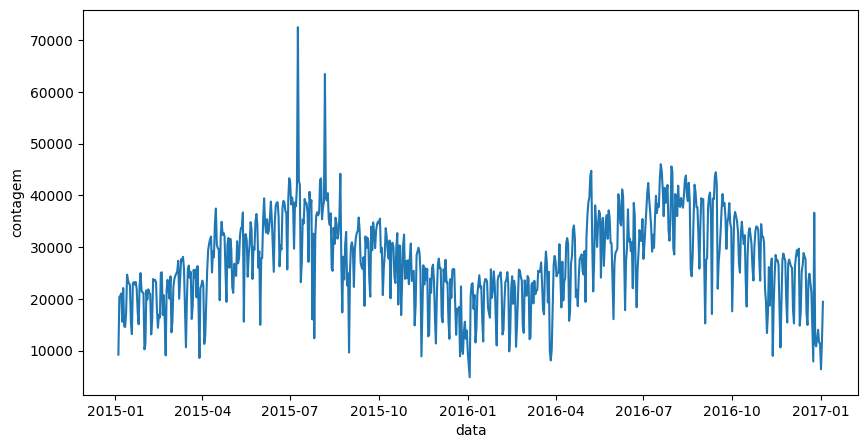

In [52]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df_tempo, x='data', y='contagem')
plt.show()

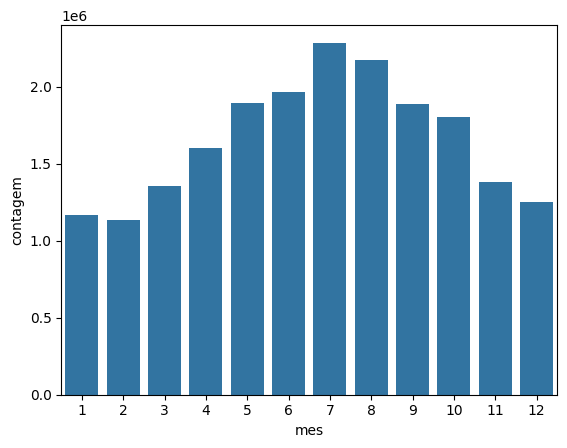

In [53]:
# Verificando distribuição por mês

alugueis_mesais = df_data.groupby('mes')['contagem'].sum().reset_index()

sns.barplot(data=alugueis_mesais, x='mes', y='contagem')
plt.show()

### Previsores com Series Temporais



In [56]:
from prophet import Prophet

In [57]:
# Para funcionamento do Prophet é necessário um dataframe com duas colunas ds(contendo datas) e y(contendo valores)

df_prophet = df_data[['data', 'contagem']].rename(columns={'data': 'ds', 'contagem': 'y'})
df_prophet.head()

,ds,y
0,2015-01-04,182
1,2015-01-04,138
2,2015-01-04,134
3,2015-01-04,72
4,2015-01-04,47


In [58]:
# Agrupando por data

df_prophet = df_prophet.groupby('ds')['y'].sum().reset_index()
df_prophet.head()

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601


In [59]:
# Necessário para a semente de aleatoriedade utilizada

import numpy as np

In [60]:
# Instanciando Prophet e realizando primeira previsão

np.random.seed(4587)
modelo = Prophet()
modelo.fit(df_prophet)
futuro = modelo.make_future_dataframe(periods = 90, freq = 'D')
previsao = modelo.predict(futuro)

10:20:46 - cmdstanpy - INFO - Chain [1] start processing
10:20:47 - cmdstanpy - INFO - Chain [1] done processing


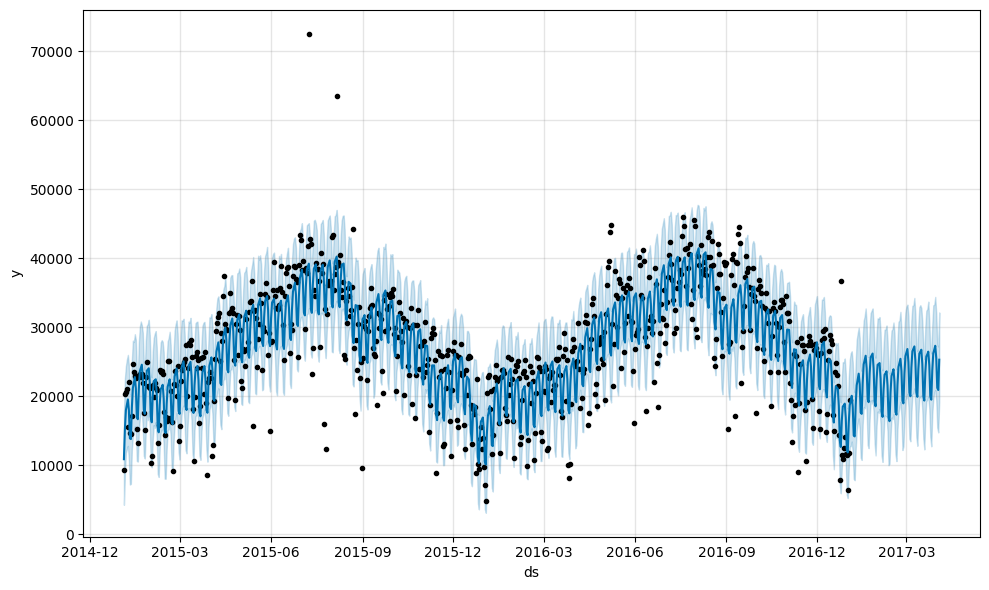

In [62]:
# Plotando previsão
# Ponto pretos - Dados reais observador
# Linha azul escuro - Previsão do modelo
# Sombra azul - Intervalo de incerteza

fig1 = modelo.plot(previsao)

In [63]:
# yhat = Valor previsto
# yhat_lower = Limite inferior de confiança
# hhat_upper = Limite superior de confiança

previsao[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2015-01-04,10867.475330,4248.720095,17121.945428
1,2015-01-05,15279.474885,8890.603831,22594.435179
2,2015-01-06,17984.467333,11808.830486,24375.241027
3,2015-01-07,18716.704031,12325.216906,25327.480077
4,2015-01-08,19529.958732,12793.147628,25988.233452
...,...,...,...,...
815,2017-03-30,27303.180612,20890.891058,34391.329492
816,2017-03-31,25530.567271,19354.657976,32029.880802
817,2017-04-01,21214.305802,15449.743958,27696.557390
818,2017-04-02,20897.178890,14749.828502,27208.645394


### O prophet é um modelo de regressao aditivo
- Utiliza componentes para realizar a previsão

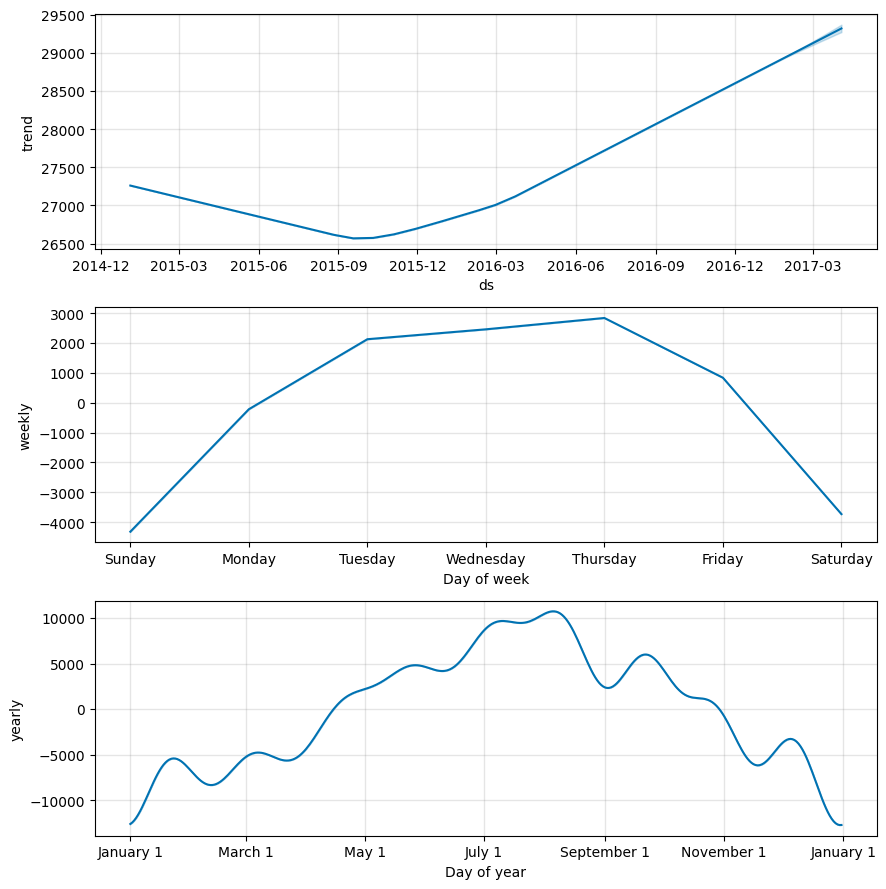

In [64]:
# Mostrando componentes de previsão

fig2 = modelo.plot_components(previsao)

## **Separando dados para treinar e testar o modelo**

In [65]:
df_prophet.shape

(730, 2)

In [66]:
# Separando 80% de dados para treino

df_treino = pd.DataFrame()

df_treino['ds'] = df_prophet['ds'][:584]
df_treino['y'] = df_prophet['y'][:584]


In [67]:
# Separando 20% de dados para teste

df_teste = pd.DataFrame()

df_teste['ds'] = df_prophet['ds'][584:]
df_teste['y'] = df_prophet['y'][584:]

In [68]:
# Realizando nova previsão com dados de treino

np.random.seed(4587)
modelo = Prophet()
modelo.fit(df_treino)
futuro = modelo.make_future_dataframe(periods = 150, freq = 'D')
previsao = modelo.predict(futuro)

10:28:39 - cmdstanpy - INFO - Chain [1] start processing
10:28:39 - cmdstanpy - INFO - Chain [1] done processing


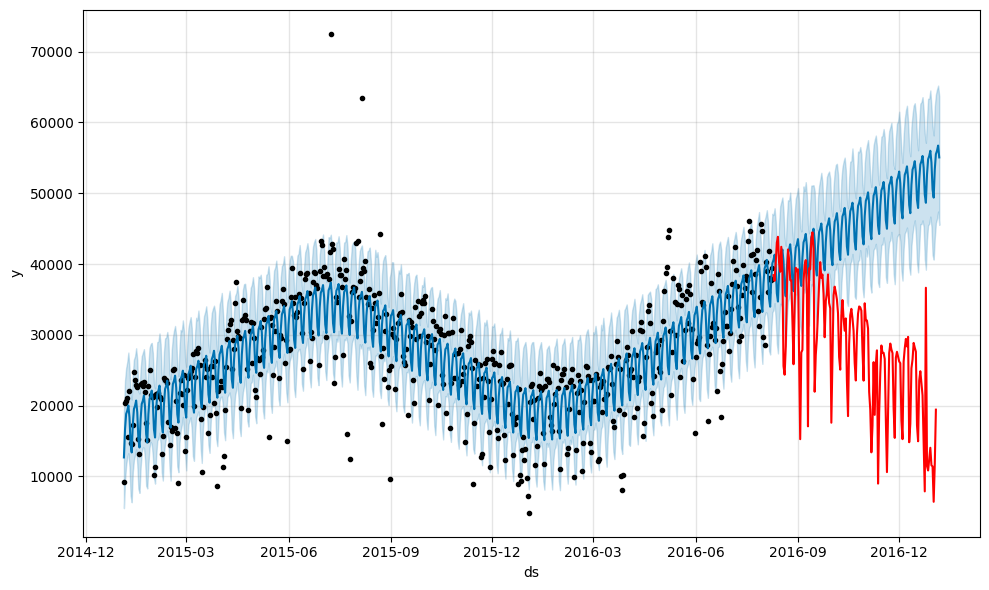

In [70]:
# A linha vermelha é o que de fato aconteceu

fig1 = modelo.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], color='red')

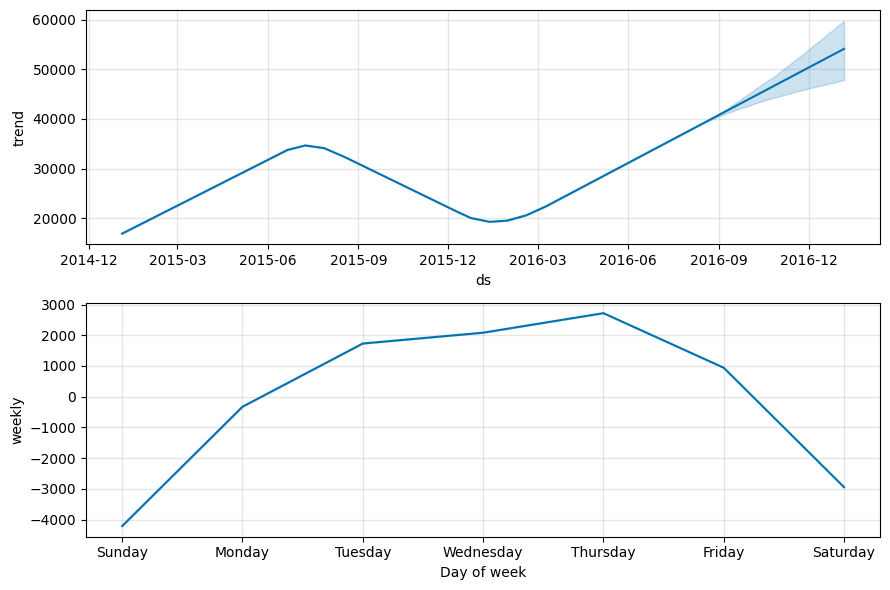

In [72]:
# Mostrando componentes

fig2 = modelo.plot_components(previsao)

## **Verificando metricas de performance do modelo**

In [73]:
# Confrontando valor real com a previsão do modelo

df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds')
df_comparacao

,ds,yhat,y
0,2016-08-10,40578.793845,38430
1,2016-08-11,41319.146737,37626
2,2016-08-12,39648.923497,40159
3,2016-08-13,35867.723149,43041
4,2016-08-14,34706.544558,43848
...,...,...,...
141,2016-12-30,54329.310462,11566
142,2016-12-31,50548.110115,11424
143,2017-01-01,49386.931524,6421
144,2017-01-02,53373.826797,11823


Utilizando o Mean Squared Error (Erro Quadrático Médio), funciona como um penalizador de erros, fazendo com que o modelo não ignore falhas gigantescas.

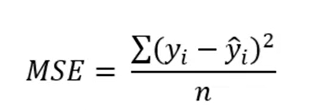

In [75]:
from sklearn.metrics import mean_squared_error

O MSE tras valores ao quadrado, para observarmos em uma unidade melhor, usamos o RMSE, onde a raiz quadrada dos valores é tirada.

In [76]:
mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat'])
rmse = np.sqrt(mse)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MSE: 461016718.87661403
RMSE: 21471.299887911166


Os valores acima mostram que o modelo está errando, em média 21471 unidades (bicicletas alugadas).

## **Melhorando o modelo**

In [77]:
# Adicionando yearly_seasonality=True, define um ponto de atenção ao modelo, solciitando que seja observado os padrão que se repetem ano após anos

np.random.seed(4587)
modelo = Prophet(yearly_seasonality=True)
modelo.fit(df_treino)
futuro = modelo.make_future_dataframe(periods = 150, freq = 'D')
previsao = modelo.predict(futuro)

10:55:11 - cmdstanpy - INFO - Chain [1] start processing
10:55:11 - cmdstanpy - INFO - Chain [1] done processing


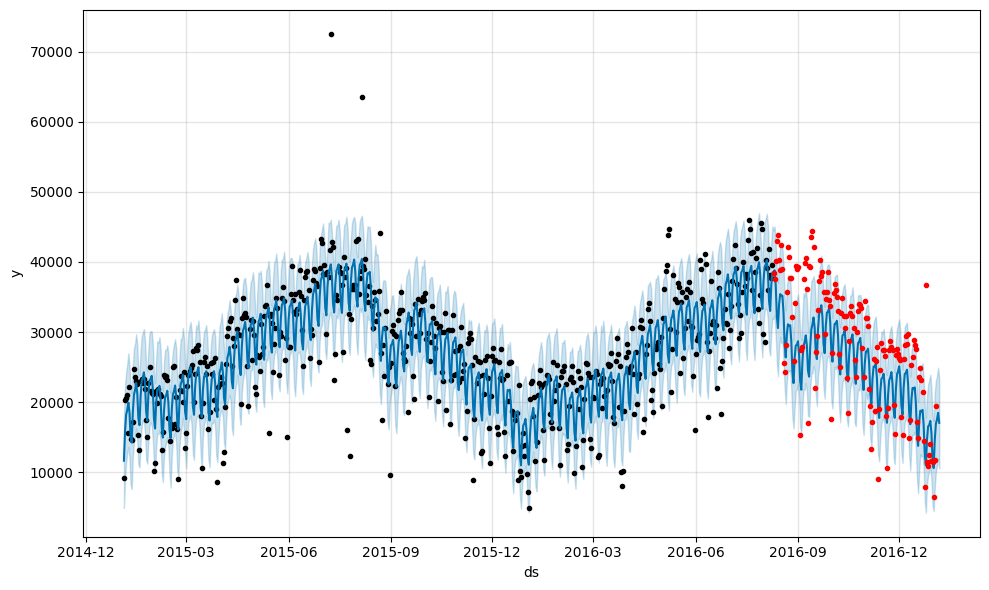

In [78]:
# Plotando após adição do hiperparametro yearly_seasonality=True

fig1 = modelo.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], '.r')

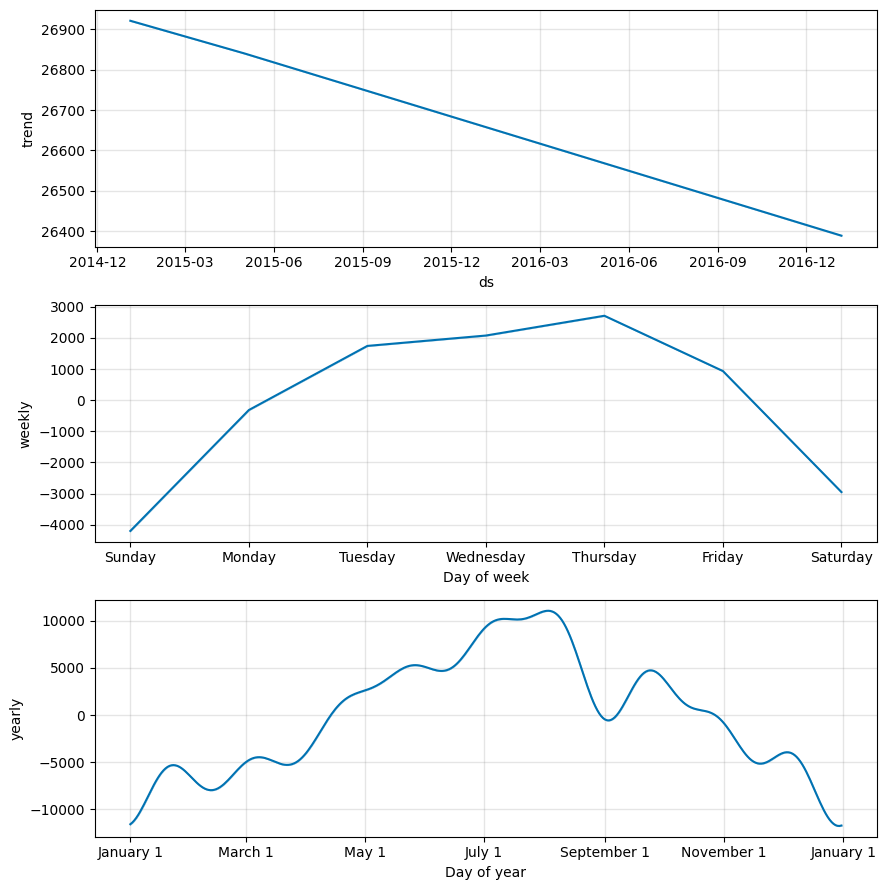

In [79]:
# Verificando componentes após inclusão do hiperparametro yearly_seasonality=True

fig2 = modelo.plot_components(previsao)

In [80]:
# Comparando valores reais com previstos

df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds')
df_comparacao

,ds,yhat,y
0,2016-08-10,38535.983587,38430
1,2016-08-11,38820.200950,37626
2,2016-08-12,36645.853380,40159
3,2016-08-13,32314.800664,43041
4,2016-08-14,30575.111820,43848
...,...,...,...
141,2016-12-30,15566.443895,11566
142,2016-12-31,11741.542288,11424
143,2017-01-01,10608.976860,6421
144,2017-01-02,14663.396759,11823


In [81]:
# Analisando novamente o MSE e RMSE

mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat'])
rmse = np.sqrt(mse)
print(f'MSE:{mse}, RMSE:{rmse}')

MSE:38023224.60959999, RMSE:6166.297479817204


## **Tratando outliers**

In [82]:
df_prophet

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601
...,...,...
725,2016-12-30,11566
726,2016-12-31,11424
727,2017-01-01,6421
728,2017-01-02,11823


In [84]:
# "Fazendo prova com consulta", gerando a previsão somente com as datas de treinamento
np.random.seed(4587)
modelo = Prophet()
modelo.fit(df_prophet)
futuro = modelo.make_future_dataframe(periods = 0)
previsao = modelo.predict(futuro)

11:07:45 - cmdstanpy - INFO - Chain [1] start processing
11:07:45 - cmdstanpy - INFO - Chain [1] done processing


In [85]:
# Criando dataframe sem outiliers, filtrando com limites inferiores e superiores

sem_outliers = df_prophet[(df_prophet['y'] > previsao['yhat_lower']) & (df_prophet['y'] < previsao['yhat_upper'])]

In [87]:
sem_outliers

,ds,y
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613
3,2015-01-07,21064
4,2015-01-08,15601
...,...,...
725,2016-12-30,11566
726,2016-12-31,11424
727,2017-01-01,6421
728,2017-01-02,11823


In [88]:
# Realizando nova divisão de treino e teste sem outliers

df_treino = pd.DataFrame()
df_treino['ds'] = sem_outliers['ds'][:505]
df_treino['y'] = sem_outliers['y'][:505]

df_teste['ds'] = sem_outliers['ds'][505:]
df_teste['y'] = sem_outliers['y'][505:]


In [89]:
# Realizando nova previsão sem outliers

np.random.seed(4587)
modelo_sem_outliers = Prophet(yearly_seasonality=True)
modelo_sem_outliers.fit(df_treino)
futuro = modelo_sem_outliers.make_future_dataframe(periods = 150, freq = 'D')
previsao = modelo_sem_outliers.predict(futuro)

11:09:36 - cmdstanpy - INFO - Chain [1] start processing
11:09:36 - cmdstanpy - INFO - Chain [1] done processing


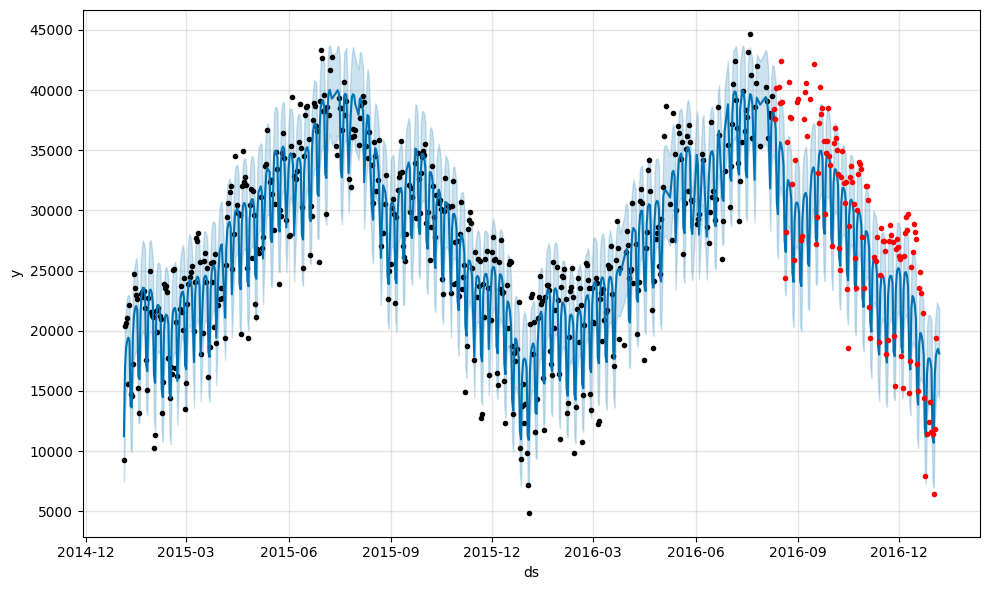

In [90]:
fig1 = modelo_sem_outliers.plot(previsao)
plt.plot(df_teste['ds'], df_teste['y'], '.r')

In [91]:
# Comparando dados reais com a previsão

df_previsao = previsao[['ds', 'yhat']]
df_comparacao = pd.merge(df_previsao, df_teste, on='ds')
df_comparacao

,ds,yhat,y
0,2016-08-10,38158.494944,38430.0
1,2016-08-11,37743.682767,37626.0
2,2016-08-12,36700.561369,40159.0
3,2016-08-15,34731.625262,40236.0
4,2016-08-16,35674.247477,38911.0
...,...,...,...
121,2016-12-30,16811.841017,11566.0
122,2016-12-31,11106.066740,11424.0
123,2017-01-01,10688.052795,6421.0
124,2017-01-02,16296.326657,11823.0


In [92]:
# Verificando MSE e RMSE

mse = mean_squared_error(df_comparacao['y'], df_comparacao['yhat'])
rmse = np.sqrt(mse)
print(f'MSE:{mse}, RMSE:{rmse}')

MSE:15478786.775128596, RMSE:3934.3089323448653


## **Expandindo previsão para o ano**

In [93]:
np.random.seed(4587)
modelo_sem_outliers = Prophet(yearly_seasonality=True)
modelo_sem_outliers.fit(df_treino)
futuro = modelo_sem_outliers.make_future_dataframe(periods = 365, freq = 'D')
previsao = modelo_sem_outliers.predict(futuro)

11:11:36 - cmdstanpy - INFO - Chain [1] start processing
11:11:36 - cmdstanpy - INFO - Chain [1] done processing


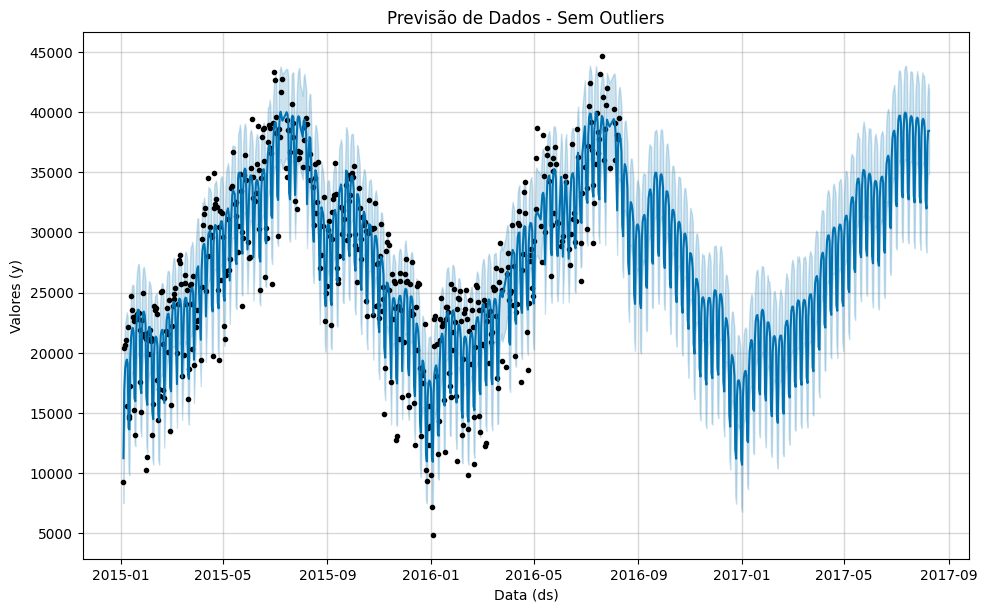

In [101]:
fig = modelo_sem_outliers.plot(previsao)
plt.title('Previsão de Dados - Sem Outliers')
plt.xlabel('Data (ds)')
plt.ylabel('Valores (y)')
plt.grid(True, alpha=0.3)

plt.show()

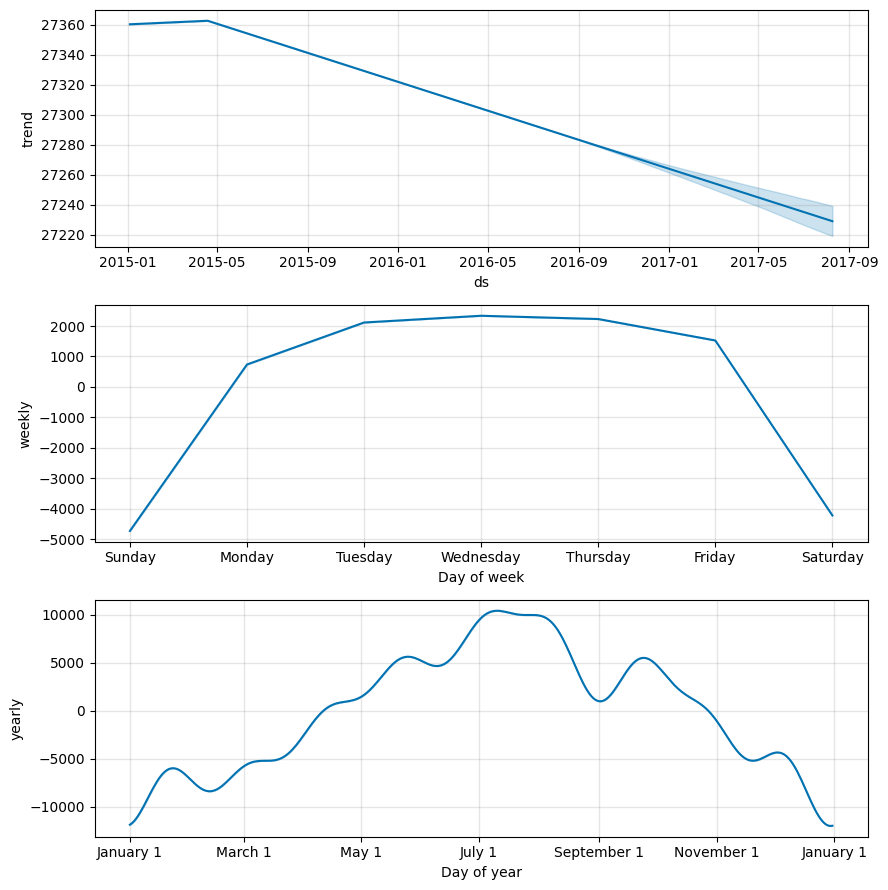

In [99]:
fig2 = modelo_sem_outliers.plot_components(previsao)